In [1]:
import numpy as np
import pandas as pd
import re
import random
import contractions
import nltk
import seaborn as sns
import matplotlib.pyplot as plt

from keras.models import Model
import tensorflow as tf
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.model_selection import train_test_split

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional, SimpleRNN, Input, SpatialDropout1D
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report


2026-06-07 21:05:59.119623: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-06-07 21:05:59.263587: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-06-07 21:06:02.050845: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')   # dependendo da versão do NLTK
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to /home/davidsales/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/davidsales/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /home/davidsales/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /home/davidsales/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /home/davidsales/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [3]:
df = pd.read_csv("IMDB Dataset.csv")

In [4]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [5]:
def preprocess(text):
    text = re.sub(r'\\', '', text)
    text = contractions.fix(text)

    text = text.lower()
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[\d\W]+', ' ', text)
    text = re.sub(r'\s{2,}', ' ', text)
    text = text.strip()

    tokens = word_tokenize(text)
    
    stop_words = set(stopwords.words('english'))
    lemmatizer = WordNetLemmatizer()

    tokens = [token for token in tokens if token not in stop_words]
    tokens = [lemmatizer.lemmatize(token) for token in tokens]
    tokens = [t for t in tokens if len(t) >= 3]

    return " ".join(tokens)

In [6]:
random_num = random.randrange(len(df))

sample_text = df.iloc[random_num]['review']
sample_text

'This film has an interesting plot, but the acting is quite bad and the script is poor. I was very disappointed. The moral dilemma faced by the main character is an intriguing one, but due to poor writing and casting this potentially winning premise is plundered. 2 of the 4 other people in the theater left after about 45 minutes and the other 2 were laughing at how bad the film was. I stuck it out to the end, but I must admit I played Blackjack on my cell phone to make the last 30 minutes bearable.'

In [7]:
print(preprocess(df.iloc[random_num]['review']))

film interesting plot acting quite bad script poor disappointed moral dilemma faced main character intriguing one due poor writing casting potentially winning premise plundered people theater left minute laughing bad film stuck end must admit played blackjack cell phone make last minute bearable


In [8]:
df['review'] = df['review'].apply(preprocess)

In [9]:
df['sentiment'] = df['sentiment'].map({'positive':1, 'negative':0})

In [10]:

X_train, X_test, y_train, y_test = train_test_split(
    df['review'], df['sentiment'],
    test_size=0.2,
    random_state=42
)

In [11]:
vocab_size = 20000

tokenizer = Tokenizer(num_words=vocab_size, oov_token="<UNK>")
tokenizer.fit_on_texts(X_train)

In [12]:
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

In [13]:
max_len = 4

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len)

# LSTM

In [54]:
lstm_model = Sequential()

lstm_model.add(Input(shape=(max_len,)))

lstm_model.add(Embedding(input_dim=vocab_size, output_dim=4))
lstm_model.add(SpatialDropout1D(0.3))

lstm_model.add((LSTM(4, dropout=0.3)))

lstm_model.add(Dropout(0.5))

lstm_model.add(Dense(4, activation='relu'))
lstm_model.add(Dropout(0.4))

lstm_model.add(Dense(1, activation='sigmoid'))

lstm_model.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=0.0005),
    metrics=['accuracy']
)

lstm_model.build(input_shape=(None, max_len))
lstm_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 4, 4)           │        80,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_3             │ (None, 4, 4)           │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 4)              │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 4)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4)              │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 4)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 80,169 (313.16 KB)

 Trainable params: 80,169 (313.16 KB)

 Non-trainable params: 0 (0.00 B)

In [55]:

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=1,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=1,
    min_lr=1e-5
)

In [56]:
lstm_history = lstm_model.fit(
    X_train_pad, y_train,
    epochs=30,
    batch_size=128,   
    validation_split=0.2,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/30


250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.5195 - loss: 0.6922 - val_accuracy: 0.5371 - val_loss: 0.6895 - learning_rate: 5.0000e-04
Epoch 2/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.5556 - loss: 0.6848 - val_accuracy: 0.6357 - val_loss: 0.6724 - learning_rate: 5.0000e-04
Epoch 3/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6139 - loss: 0.6655 - val_accuracy: 0.6712 - val_loss: 0.6438 - learning_rate: 5.0000e-04
Epoch 4/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6505 - loss: 0.6424 - val_accuracy: 0.6802 - val_loss: 0.6239 - learning_rate: 5.0000e-04
Epoch 5/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6783 - loss: 0.6216 - val_accuracy: 0.6784 - val_loss: 0.6125 - learning_rate: 5.0000e-04
Epoch 6/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6880 - loss: 0.6072 - val_accuracy: 0.6784 - val_loss: 0.6065 - learning_rate: 5.0000e-04
Epoch 7/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6990 - lo

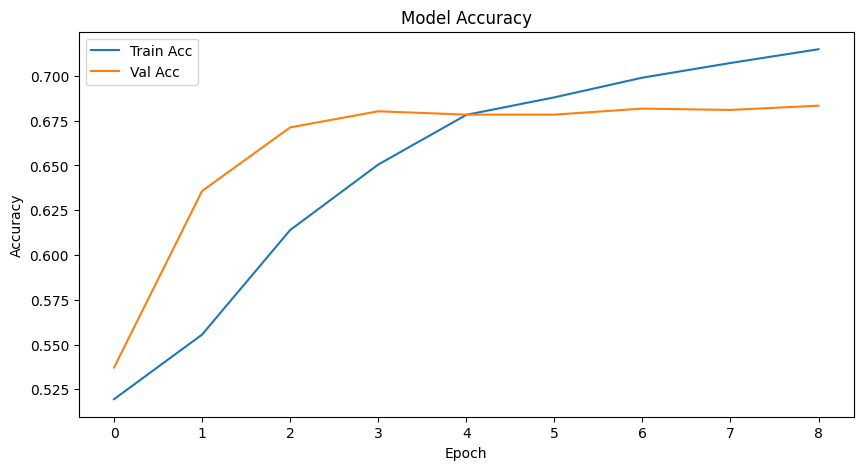

In [57]:
plt.figure(figsize=(10,5))

plt.plot(lstm_history.history['accuracy'], label='Train Acc')
plt.plot(lstm_history.history['val_accuracy'], label='Val Acc')

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [58]:
lstm_loss, lstm_acc = lstm_model.evaluate(X_test_pad, y_test)
print("Test Accuracy:", lstm_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6931 - loss: 0.5955
Test Accuracy: 0.6930999755859375


## Confusion Matrices

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


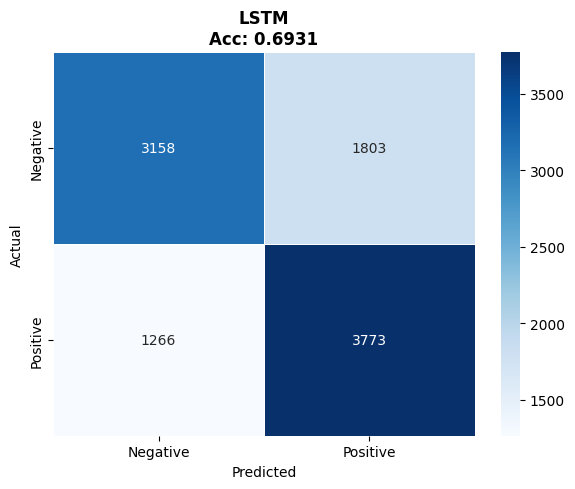

In [59]:
y_pred_lstm = (lstm_model.predict(X_test_pad) > 0.5).astype(int).flatten()

cm = confusion_matrix(y_test, y_pred_lstm)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Negative', 'Positive'],
    yticklabels=['Negative', 'Positive'],
    linewidths=0.5,
    linecolor='white'
)

acc = (y_pred_lstm == y_test.values).mean()

plt.title(f'LSTM\nAcc: {acc:.4f}', fontsize=12, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.tight_layout()
plt.show()

## Classification Reports

In [60]:
for name, pred in zip(['LSTM'], [ y_pred_lstm]):
    print(f"{'='*45}")
    print(f"  {name} — Classification Report")
    print(f"{'='*45}")
    print(classification_report(y_test, pred, target_names=['Negative','Positive']))

  LSTM — Classification Report
              precision    recall  f1-score   support

    Negative       0.71      0.64      0.67      4961
    Positive       0.68      0.75      0.71      5039

    accuracy                           0.69     10000
   macro avg       0.70      0.69      0.69     10000
weighted avg       0.70      0.69      0.69     10000



In [61]:
dummy = tf.zeros((1, max_len), dtype=tf.int32)
_ = lstm_model(dummy)

In [62]:
texto_natural = "The movie was terrible"
texto_sem_stopwords = preprocess(texto_natural)

In [63]:
teste_qualquer = tokenizer.texts_to_sequences([texto_sem_stopwords])
teste_qualquer_pad = pad_sequences(teste_qualquer, maxlen=max_len)


In [64]:
# modelo de inspeção
layer_outputs = [layer.output for layer in lstm_model.layers]

inspection_model = Model(
    inputs=lstm_model.inputs,
    outputs=layer_outputs
)

# entrada exemplo
x = teste_qualquer_pad

# forward
outputs = inspection_model.predict(x)

# salva em txt
with open("layer_outputs.txt", "w", encoding="utf-8") as f:

    for layer, output in zip(lstm_model.layers, outputs):

        f.write(f"\n{'='*60}\n")
        f.write(f"Camada: {layer.name}\n")
        f.write(f"Shape: {output.shape}\n")
        f.write(f"{'='*60}\n\n")

        # converte numpy array para string
        np.set_printoptions(threshold=np.inf)

        f.write(np.array2string(
            output,
            separator=', ',
            precision=6
        ))

        f.write("\n\n")

print("Outputs salvos em layer_outputs.txt")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 684ms/step
Outputs salvos em layer_outputs.txt


In [65]:

FRAC = 16
SCALE = 1 << FRAC

INT32_MAX = np.int32(2**31 - 1)
INT32_MIN = np.int32(-(2**31))

def float_to_q16(val):
    if np.isnan(val):
        return np.int32(0)
    if np.isposinf(val):
        return INT32_MAX
    if np.isneginf(val):
        return INT32_MIN
    fixed = np.round(val * SCALE)
    return np.int32(fixed)

# ============================================================
# ENDERECO DE 21 BITS
# ============================================================
def build_addr(layer, is_bias, is_lstm, gate, neuron, recurrent, idx):
    addr = 0
    addr |= (layer     & 0xF)   << 17  # bits 20-17: camada (max 16)
    addr |= (is_bias   & 0x1)   << 16  # bit 16:    bias
    addr |= (is_lstm   & 0x1)   << 15  # bit 15:    lstm
    addr |= (gate      & 0x3)   << 13  # bits 14-13: porta LSTM
    addr |= (neuron    & 0x3F)  << 7   # bits 12-7:  neuronio (max 64)
    addr |= (recurrent & 0x1)   << 6   # bit 6:     recorrente
    addr |= (idx       & 0x3F)        # bits 5-0:   indice (max 64)
    return addr

# ============================================================
# EXPORTA PESOS DA LSTM (ignorando Embedding)
# ============================================================
def export_lstm_weights(model, output_file="weights_lstm.mem"):
    print("\n" + "="*50)
    print("MODO LSTM: Exportando pesos a partir da primeira LSTM")
    print("Ignorando: Embedding e SpatialDropout1D")
    print("="*50)
    
    mem = {}
    layer_idx = 0  # camada 0 = primeira LSTM
    
    # Percorre as camadas do modelo
    for layer in model.layers:
        # Pula camadas que nao tem pesos
        if len(layer.get_weights()) == 0:
            continue
            
        # Verifica se é LSTM (incluindo Bidirectional)
        if isinstance(layer, Bidirectional):
            # Bidirectional tem 2 LSTMs (forward e backward)
            print(f"\nCamada {layer_idx}: Bidirectional LSTM")
            
            forward_lstm = layer.forward_layer
            backward_lstm = layer.backward_layer
            
            # Exporta forward LSTM
            export_lstm_core(forward_lstm, mem, layer_idx, direction=0)
            # Exporta backward LSTM (proxima camada)
            export_lstm_core(backward_lstm, mem, layer_idx + 1, direction=1)
            
            layer_idx += 2  # Duas camadas (forward e backward)
            
        elif isinstance(layer, LSTM):
            print(f"\nCamada {layer_idx}: LSTM")
            export_lstm_core(layer, mem, layer_idx, direction=0)
            layer_idx += 1
            
        elif isinstance(layer, Dense):
            print(f"\nCamada {layer_idx}: Dense")
            export_dense_core(layer, mem, layer_idx)
            layer_idx += 1
    
    # Salva arquivo
    with open(output_file, "w") as f:
        for addr in sorted(mem.keys()):
            val = np.int32(mem[addr])
            f.write(f"{int(addr):05x} {int(val) & 0xFFFFFFFF:08X}\n")
    
    print(f"\nArquivo salvo: {output_file}")
    print(f"Total de pesos: {len(mem)}")
    return mem

# ============================================================
# EXPORTA PESOS DA LSTM (core)
# ============================================================
def export_lstm_core(lstm_layer, mem, layer_idx, direction=0):
    """
    Exporta pesos de uma camada LSTM
    direction: 0 = forward, 1 = backward (apenas para identificacao)
    """
    weights = lstm_layer.get_weights()
    
    # LSTM tem 3 matrizes de pesos e 3 biases (ou 2 se usar bias=False)
    # weights[0]: kernel (input weights) - formato: (input_dim, 4 * units)
    # weights[1]: recurrent_kernel (recurrent weights) - formato: (units, 4 * units)
    # weights[2]: bias (se existir) - formato: (4 * units,)
    
    units = lstm_layer.units
    input_dim = weights[0].shape[0]
    
    # Separa os pesos para cada porta (forget, input, candidate, output)
    # Ordem: i, f, c, o (input, forget, candidate, output)
    kernel = weights[0].T  # Transpoe para (4*units, input_dim)
    recurrent_kernel = weights[1].T  # Transpoe para (4*units, units)
    
    # Bias
    has_bias = len(weights) > 2
    if has_bias:
        bias = weights[2]
    else:
        bias = np.zeros(4 * units)
    
    # Para cada porta
    gates = ['forget', 'input', 'candidate', 'output']
    
    for gate_idx, gate_name in enumerate(gates):
        # Pesos de entrada (Wx)
        kernel_gate = kernel[gate_idx * units:(gate_idx + 1) * units, :]
        for n in range(units):
            for inp in range(input_dim):
                addr = build_addr(
                    layer=layer_idx,
                    is_bias=0,
                    is_lstm=1,
                    gate=gate_idx,
                    neuron=n,
                    recurrent=0,
                    idx=inp
                )
                mem[addr] = float_to_q16(kernel_gate[n, inp])
                
                # Mostra alguns exemplos (opcional)
                if n < 2 and inp < 2:
                    print(f"  addr=0x{addr:05X} Wx_{gate_name}[{n}][{inp}] = {kernel_gate[n, inp]:.6f}")
        
        # Pesos recorrentes (Wh)
        rec_gate = recurrent_kernel[gate_idx * units:(gate_idx + 1) * units, :]
        for n in range(units):
            for prev_n in range(units):
                addr = build_addr(
                    layer=layer_idx,
                    is_bias=0,
                    is_lstm=1,
                    gate=gate_idx,
                    neuron=n,
                    recurrent=1,
                    idx=prev_n
                )
                mem[addr] = float_to_q16(rec_gate[n, prev_n])
                
                if n < 2 and prev_n < 2:
                    print(f"  addr=0x{addr:05X} Wh_{gate_name}[{n}][{prev_n}] = {rec_gate[n, prev_n]:.6f}")
        
        # Bias
        bias_gate = bias[gate_idx * units:(gate_idx + 1) * units]
        for n in range(units):
            addr = build_addr(
                layer=layer_idx,
                is_bias=1,
                is_lstm=1,
                gate=gate_idx,
                neuron=n,
                recurrent=0,
                idx=0
            )
            mem[addr] = float_to_q16(bias_gate[n])
            
            if n < 2:
                print(f"  addr=0x{addr:05X} bias_{gate_name}[{n}] = {bias_gate[n]:.6f}")

# ============================================================
# EXPORTA PESOS DA DENSE (MLP comum)
# ============================================================
def export_dense_core(dense_layer, mem, layer_idx):
    """Exporta pesos de uma camada Dense"""
    weights = dense_layer.get_weights()
    
    if len(weights) >= 1:
        kernel = weights[0].T  # Transpoe para (output_dim, input_dim)
        n_neurons, n_inputs = kernel.shape
        
        # Pesos
        for n in range(n_neurons):
            for inp in range(n_inputs):
                addr = build_addr(
                    layer=layer_idx,
                    is_bias=0,
                    is_lstm=0,  # Nao é LSTM
                    gate=0,
                    neuron=n,
                    recurrent=0,
                    idx=inp
                )
                mem[addr] = float_to_q16(kernel[n, inp])
                
                if n < 3 and inp < 3:
                    print(f"  addr=0x{addr:05X} weight[{n}][{inp}] = {kernel[n, inp]:.6f}")
        
        # Biases
        if len(weights) >= 2:
            bias = weights[1]
            for n in range(n_neurons):
                addr = build_addr(
                    layer=layer_idx,
                    is_bias=1,
                    is_lstm=0,
                    gate=0,
                    neuron=n,
                    recurrent=0,
                    idx=0
                )
                mem[addr] = float_to_q16(bias[n])
                
                if n < 3:
                    print(f"  addr=0x{addr:05X} bias[{n}] = {bias[n]:.6f}")

# ============================================================
# EXPORTA COMO MLP (ignorando LSTM)
# ============================================================
def export_mlp_weights(model, output_file="weights_mlp.mem"):
    print("\n" + "="*50)
    print("MODO MLP: Exportando pesos como rede neural comum")
    print("Todas as camadas Dense sao consideradas")
    print("="*50)
    
    mem = {}
    layer_idx = 0
    
    for layer in model.layers:
        if len(layer.get_weights()) == 0:
            continue
            
        if isinstance(layer, Dense):
            print(f"\nCamada {layer_idx}: Dense")
            export_dense_core(layer, mem, layer_idx)
            layer_idx += 1
        elif isinstance(layer, Bidirectional) or isinstance(layer, LSTM):
            print(f"\nAviso: Pulando camada LSTM no modo MLP")
            continue
    
    with open(output_file, "w") as f:
        for addr in sorted(mem.keys()):
            val = np.int32(mem[addr])
            f.write(f"{int(addr):05x} {int(val) & 0xFFFFFFFF:08X}\n")
    
    print(f"\nArquivo salvo: {output_file}")
    print(f"Total de pesos: {len(mem)}")
    return mem

# ============================================================
# FUNCAO PRINCIPAL
# ============================================================
def export_weights(model, mode='lstm', output_file=None):
    """
    Exporta pesos do modelo
    
    Args:
        model: Modelo Keras
        mode: 'lstm' (ignora Embedding) ou 'mlp' (apenas camadas Dense)
        output_file: Nome do arquivo de saida
    """
    if mode == 'lstm':
        if output_file is None:
            output_file = "weights_lstm.mem"
        return export_lstm_weights(model, output_file)
    elif mode == 'mlp':
        if output_file is None:
            output_file = "weights_mlp.mem"
        return export_mlp_weights(model, output_file)
    else:
        raise ValueError("Modo deve ser 'lstm' ou 'mlp'")



In [66]:
export_weights(lstm_model, mode='lstm', output_file="weights_lstm.mem")


print("\n" + "#"*60)
print("CONCLUIDO!")
print("#"*60)


MODO LSTM: Exportando pesos a partir da primeira LSTM
Ignorando: Embedding e SpatialDropout1D

Camada 0: LSTM
  addr=0x08000 Wx_forget[0][0] = 0.048507
  addr=0x08001 Wx_forget[0][1] = 0.587897
  addr=0x08080 Wx_forget[1][0] = -0.096939
  addr=0x08081 Wx_forget[1][1] = 0.142086
  addr=0x08040 Wh_forget[0][0] = -0.528478
  addr=0x08041 Wh_forget[0][1] = -0.490525
  addr=0x080C0 Wh_forget[1][0] = -0.402586
  addr=0x080C1 Wh_forget[1][1] = -0.769230
  addr=0x18000 bias_forget[0] = 0.485368
  addr=0x18080 bias_forget[1] = 0.477546
  addr=0x0A000 Wx_input[0][0] = 0.179418
  addr=0x0A001 Wx_input[0][1] = 0.597438
  addr=0x0A080 Wx_input[1][0] = 0.956474
  addr=0x0A081 Wx_input[1][1] = 0.931743
  addr=0x0A040 Wh_input[0][0] = -0.009470
  addr=0x0A041 Wh_input[0][1] = -0.028156
  addr=0x0A0C0 Wh_input[1][0] = -0.463849
  addr=0x0A0C1 Wh_input[1][1] = 0.036138
  addr=0x1A000 bias_input[0] = 1.262573
  addr=0x1A080 bias_input[1] = 1.199703
  addr=0x0C000 Wx_candidate[0][0] = -0.856441
  addr=0x

In [74]:
lstm_model.weights[2][0]

<tf.Tensor: shape=(16,), dtype=float32, numpy=
array([-0.5284784 , -0.40258554, -0.6651165 ,  0.27265692, -0.00946971,
       -0.46384865, -0.19196439, -0.31084672,  0.39359134,  0.3837719 ,
       -0.8209942 , -0.5545625 , -0.18786512, -0.6446733 , -0.42898428,
       -0.1427755 ], dtype=float32)>

In [76]:
lstm_model.weights[5]

<Variable path=sequential_3/dense_4/bias, shape=(4,), dtype=float32, value=[0.11673222 0.0787391  0.09290441 0.07676689]>

In [67]:
# Modo 1: A partir da LSTM (ignorando Embedding)
#export_weights(lstm_model, mode='lstm', output_file="weights_lstm.mem")

# Modo 2: Como MLP comum (apenas camadas Dense)
export_weights(lstm_model, mode='mlp', output_file="weights_mlp.mem")

print("\n" + "#"*60)
print("CONCLUIDO!")
print("#"*60)


MODO MLP: Exportando pesos como rede neural comum
Todas as camadas Dense sao consideradas

Aviso: Pulando camada LSTM no modo MLP

Camada 0: Dense
  addr=0x00000 weight[0][0] = -0.863895
  addr=0x00001 weight[0][1] = -0.351848
  addr=0x00002 weight[0][2] = 0.580879
  addr=0x00080 weight[1][0] = -0.809002
  addr=0x00081 weight[1][1] = -1.062206
  addr=0x00082 weight[1][2] = 0.553156
  addr=0x00100 weight[2][0] = -0.707694
  addr=0x00101 weight[2][1] = -0.428340
  addr=0x00102 weight[2][2] = 0.863095
  addr=0x10000 bias[0] = 0.116732
  addr=0x10080 bias[1] = 0.078739
  addr=0x10100 bias[2] = 0.092904

Camada 1: Dense
  addr=0x20000 weight[0][0] = -0.810813
  addr=0x20001 weight[0][1] = -1.395926
  addr=0x20002 weight[0][2] = -1.284700
  addr=0x30000 bias[0] = 0.525034

Arquivo salvo: weights_mlp.mem
Total de pesos: 25

############################################################
CONCLUIDO!
############################################################
